# Rationale for Updates:
- **Tile Size (256x256)**: Increased from 224 to 256 to match standard input size for ConvNeXt.
- **Dataset Size (40k tiles)**: Shifted target output tiles to 40,000 for faster prototyping and a tightly balanced set.
- **Dedicated Output Directory**: Ensured assets will not overlap by routing all generations to a new folder: `dataset_256_40k`.


In [1]:
# %% [markdown]
# # CellViT Tile Dataset Builder - Balanced Sampling Strategy (REVISED)

# **Key Insight: Slides can appear in multiple splits, but individual tiles cannot**

# **Revised Approach:**
# 1. **Tile-level splitting** (not slide-level) - Same slide can contribute to train/val/test
# 2. **Spatial non-overlap guarantee** - Tiles are non-overlapping within each slide
# 3. **Stratified tile assignment** - Balance classes across splits at the tile level
# 4. **Two-stage sampling**: 
#    - Stage 1: Generate ALL candidate tiles from all slides
#    - Stage 2: Assign tiles to splits based on class balance needs

# %% [markdown]

In [ ]:
## 1. Setup & Load Cell Distribution Data
import json
import random
import sys
from dataclasses import dataclass, field
from collections import Counter, defaultdict
from pathlib import Path
from typing import Dict, List, Set, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

# Add CellViT repo to path
CELLVIT_REPO = Path(r"C:\Users\Andre\cursor_projects\CellViT-plus-plus")
sys.path.insert(0, str(CELLVIT_REPO))

# Configuration
CELL_COUNTS_CSV = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\cell_type_analysis\cell_counts_per_slide.csv")
GEOJSON_DIR = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\geojson_CODAclass")
MANIFEST_JSON = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\GS40_manifest.json")
OUT_DIR = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_256_40k_48_slides")
NDPI_BASE_DIR = Path(r"\\kittyserverdw\Andre_kit\data\monkey_fetus\gestational 40")

# Resolution parameters (MPP)
MPP_20X = 0.4416   # Base resolution (0.4416 um/px)
MPP_BB  = 4        # 2.5x Bounding Box scale
MPP_MASK = 2       # 5x Segmentation Mask scale

LABELS = [
    "bone", "brain", "eye", "heart", "lungs", "GI", "liver", "spleen", 
    "pancreas", "kidney", "mesokidney", "collagen", "ear", "nontissue", 
    "thymus", "thyroid", "bladder", "skull", "spleen2"
]

COLORS = [
    [214, 212, 161], [247, 184, 67], [136, 232, 95], [140, 13, 13], 
    [38, 27, 166], [13, 125, 11], [179, 50, 108], [228, 235, 131], 
    [156, 96, 235], [46, 190, 230], [150, 255, 245], [254, 222, 255], 
    [235, 154, 108], [255, 255, 255], [9, 64, 116], [255, 255, 74], 
    [178, 178, 0], [214, 212, 161], [54, 83, 89]
]

print(f"Cell counts CSV: {CELL_COUNTS_CSV.exists()}")
print(f"GeoJSON directory: {GEOJSON_DIR.exists()}")
print(f"Manifest JSON: {MANIFEST_JSON.exists()}")


Cell counts CSV: True
GeoJSON directory: True
Manifest JSON: False


In [3]:
# %% SECTION 2: Load and Analyze Class Distribution
# Load cell distribution data
df_counts = pd.read_csv(CELL_COUNTS_CSV, index_col=0)

# Remove TOTAL column if present
if "TOTAL" in df_counts.columns:
    df_counts = df_counts.drop(columns=["TOTAL"])

# Calculate overall class distribution
class_totals = df_counts.sum(axis=0).sort_values(ascending=False)
total_cells = class_totals.sum()

print("="*70)
print("CLASS DISTRIBUTION ANALYSIS")
print("="*70)
print(f"\nTotal cells: {total_cells:,}")
print(f"Number of classes: {len(class_totals)}")

# Categorize classes by frequency
rare_threshold_cells = total_cells * 0.01  # < 1% of total
common_threshold_cells = total_cells * 0.10  # > 10% of total

rare_classes = []
medium_classes = []
common_classes = []

print(f"\n{'Class':<25} {'Count':>12} {'% of Total':>12} {'Category':>15}")
print("-"*70)

for cls, count in class_totals.items():
    pct = (count / total_cells) * 100
    
    if count < rare_threshold_cells:
        category = "RARE"
        rare_classes.append(cls)
    elif count > common_threshold_cells:
        category = "COMMON"
        common_classes.append(cls)
    else:
        category = "MEDIUM"
        medium_classes.append(cls)
    
    print(f"{cls:<25} {count:>12,} {pct:>11.2f}% {category:>15}")

print("\n" + "="*70)
print("SAMPLING STRATEGY CATEGORIES")
print("="*70)
print(f"Rare classes ({len(rare_classes)}): {', '.join(rare_classes)}")
print(f"Medium classes ({len(medium_classes)}): {', '.join(medium_classes)}")
print(f"Common classes ({len(common_classes)}): {', '.join(common_classes)}")


CLASS DISTRIBUTION ANALYSIS

Total cells: 18,289,085
Number of classes: 19

Class                            Count   % of Total        Category
----------------------------------------------------------------------
collagen                     7,810,265       42.70%          COMMON
brain                        4,846,700       26.50%          COMMON
liver                        2,385,118       13.04%          COMMON
bone                         1,415,191        7.74%          MEDIUM
nontissue                      406,463        2.22%          MEDIUM
GI                             344,343        1.88%          MEDIUM
skull                          278,899        1.52%          MEDIUM
lungs                          211,363        1.16%          MEDIUM
heart                          133,450        0.73%            RARE
eye                             86,371        0.47%            RARE
mesokidney                      81,261        0.44%            RARE
spleen                          66,37

In [4]:
# %% SECTION 3: Calculate Hybrid Sampling Weights (FIXED v2)
def calculate_hybrid_weights_fixed(class_counts: pd.Series, 
                                   rare_threshold_pct: float = 0.01,
                                   common_threshold_pct: float = 0.10) -> pd.Series:
    """
    Calculate hybrid sampling weights with different strategies per tier.
    
    Strategy:
    - Rare classes (<1%): Oversample to match medium class median
    - Medium classes (1-10%): Use as reference (minimal adjustment)
    - Common classes (>10%): Moderate downsampling to median of medium classes
    
    Args:
        class_counts: Series with cell counts per class
        rare_threshold_pct: Percentage threshold for rare classes (default 1%)
        common_threshold_pct: Percentage threshold for common classes (default 10%)
    
    Returns:
        Series with sampling weights per class
    """
    total = class_counts.sum()
    weights = pd.Series(index=class_counts.index, dtype=float)
    
    # Identify thresholds
    rare_threshold = total * rare_threshold_pct
    common_threshold = total * common_threshold_pct
    
    # Get medium class counts for reference (these are our "balanced" target)
    medium_mask = (class_counts >= rare_threshold) & (class_counts < common_threshold)
    if medium_mask.sum() > 0:
        median_medium = class_counts[medium_mask].median()
    else:
        median_medium = class_counts.median()
    
    print(f"Reference (median of medium classes): {median_medium:,.0f} cells")
    
    for cls, count in class_counts.items():
        if count < rare_threshold:
            # RARE: Oversample to match median of medium classes
            # This ensures rare classes get adequate representation
            weights[cls] = median_medium / count
            # Cap at 10x to avoid extreme oversampling
            weights[cls] = min(weights[cls], 10.0)
            
        elif count < common_threshold:
            # MEDIUM: Keep as-is (reference point)
            weights[cls] = 1.0
            
        else:
            # COMMON: Downsample to median of medium classes
            # This prevents common classes from dominating
            weights[cls] = median_medium / count
            # But don't downsample below 20% of original
            weights[cls] = max(weights[cls], 0.2)
    
    return weights

# Calculate weights
hybrid_weights = calculate_hybrid_weights_fixed(class_totals, 0.01, 0.10)
hybrid_targets = (class_totals * hybrid_weights).round().astype(int)

print("\n" + "="*70)
print("HYBRID SAMPLING WEIGHTS (FIXED)")
print("="*70)
print(f"{'Class':<25} {'Current':>12} {'Weight':>10} {'Target':>12} {'Change':>10} {'Category':>12}")
print("-"*70)

for cls in class_totals.index:
    current = class_totals[cls]
    weight = hybrid_weights[cls]
    target = hybrid_targets[cls]
    change = ((target - current) / current * 100)
    
    # Identify category
    if current < rare_threshold_cells:
        category = "RARE"
    elif current > common_threshold_cells:
        category = "COMMON"
    else:
        category = "MEDIUM"
    
    print(f"{cls:<25} {current:>12,} {weight:>10.2f} {target:>12,} {change:>9.1f}% {category:>12}")

print(f"\nTotal current cells: {class_totals.sum():,}")
print(f"Total target cells: {hybrid_targets.sum():,}")
print(f"Overall change: {((hybrid_targets.sum() - class_totals.sum()) / class_totals.sum() * 100):.1f}%")

# Show balancing effect
print("\n" + "="*70)
print("BALANCING EFFECT")
print("="*70)
print(f"Before: Max/Min ratio = {class_totals.max() / class_totals.min():.1f}x")
print(f"After:  Max/Min ratio = {hybrid_targets.max() / hybrid_targets.min():.1f}x")
print(f"\nReduction in imbalance: {(1 - (hybrid_targets.max() / hybrid_targets.min()) / (class_totals.max() / class_totals.min())) * 100:.1f}%")

Reference (median of medium classes): 344,343 cells

HYBRID SAMPLING WEIGHTS (FIXED)
Class                          Current     Weight       Target     Change     Category
----------------------------------------------------------------------
collagen                     7,810,265       0.20    1,562,053     -80.0%       COMMON
brain                        4,846,700       0.20      969,340     -80.0%       COMMON
liver                        2,385,118       0.20      477,024     -80.0%       COMMON
bone                         1,415,191       1.00    1,415,191       0.0%       MEDIUM
nontissue                      406,463       1.00      406,463       0.0%       MEDIUM
GI                             344,343       1.00      344,343       0.0%       MEDIUM
skull                          278,899       1.00      278,899       0.0%       MEDIUM
lungs                          211,363       1.00      211,363       0.0%       MEDIUM
heart                          133,450       2.58      344,34

In [5]:
# %% SECTION 3: Calculate Hybrid Sampling Weights (FINAL - NUANCED 4-TIER)
def calculate_hybrid_weights_nuanced(class_counts: pd.Series, 
                                     rare_threshold_pct: float = 0.01,
                                     medium_threshold_pct: float = 0.10,
                                     very_common_threshold_pct: float = 0.20) -> pd.Series:
    """
    Nuanced 4-tier downsampling strategy:
    - RARE (<1%): Oversample to reference (up to 10x)
    - MEDIUM (1-10%): Moderate adjustment (50-128% of original)
    - COMMON (10-20%): Moderate downsampling (30% of reference = ~10% of original for liver)
    - VERY COMMON (>20%): Aggressive downsampling (10% of reference = ~5% of original)
    """
    total = class_counts.sum()
    weights = pd.Series(index=class_counts.index, dtype=float)
    
    # Identify thresholds
    rare_threshold = total * rare_threshold_pct
    medium_threshold = total * medium_threshold_pct
    very_common_threshold = total * very_common_threshold_pct
    
    # Get medium class counts for reference
    medium_mask = (class_counts >= rare_threshold) & (class_counts < medium_threshold)
    if medium_mask.sum() > 0:
        median_medium = class_counts[medium_mask].median()
    else:
        median_medium = class_counts.median()
    
    # Target: Keep medium classes around 70% of their median
    target_reference = median_medium * 0.7
    
    print(f"Target reference (70% of medium median): {target_reference:,.0f} cells")
    print(f"\nThresholds:")
    print(f"  RARE: < {rare_threshold:,.0f} ({rare_threshold_pct*100:.1f}%)")
    print(f"  MEDIUM: {rare_threshold:,.0f} - {medium_threshold:,.0f} ({rare_threshold_pct*100:.1f}%-{medium_threshold_pct*100:.1f}%)")
    print(f"  COMMON: {medium_threshold:,.0f} - {very_common_threshold:,.0f} ({medium_threshold_pct*100:.1f}%-{very_common_threshold_pct*100:.1f}%)")
    print(f"  VERY COMMON: > {very_common_threshold:,.0f} (>{very_common_threshold_pct*100:.1f}%)")
    
    for cls, count in class_counts.items():
        pct = count / total
        
        if pct < rare_threshold_pct:
            # RARE: Oversample to reference level
            weights[cls] = target_reference / count
            weights[cls] = min(weights[cls], 10.0)  # Cap at 10x
            
        elif pct < medium_threshold_pct:
            # MEDIUM: Moderate adjustment to reference
            weights[cls] = target_reference / count
            weights[cls] = max(weights[cls], 0.5)  # Don't go below 50%
            
        elif pct < very_common_threshold_pct:
            # COMMON (like liver): Moderate downsampling to 30% of reference
            target_common = target_reference * 0.3
            weights[cls] = target_common / count
            weights[cls] = max(weights[cls], 0.10)  # Don't go below 10%
            
        else:
            # VERY COMMON (collagen, brain): Aggressive downsampling to 10% of reference
            target_very_common = target_reference * 0.1
            weights[cls] = target_very_common / count
            weights[cls] = max(weights[cls], 0.05)  # Don't go below 5%
    
    return weights

# Calculate final weights
hybrid_weights = calculate_hybrid_weights_nuanced(class_totals, 0.01, 0.10, 0.20)
hybrid_targets = (class_totals * hybrid_weights).round().astype(int)

print("\n" + "="*70)
print("FINAL HYBRID SAMPLING WEIGHTS (4-TIER NUANCED)")
print("="*70)
print(f"{'Class':<25} {'Current':>12} {'%':>7} {'Weight':>10} {'Target':>12} {'Change':>10} {'Tier':>15}")
print("-"*100)

for cls in class_totals.index:
    current = class_totals[cls]
    pct = (current / total_cells) * 100
    weight = hybrid_weights[cls]
    target = hybrid_targets[cls]
    change = ((target - current) / current * 100)
    
    if pct < 1.0:
        tier = "RARE"
    elif pct < 10.0:
        tier = "MEDIUM"
    elif pct < 20.0:
        tier = "COMMON"
    else:
        tier = "VERY COMMON"
    
    print(f"{cls:<25} {current:>12,} {pct:>6.1f}% {weight:>10.2f} {target:>12,} {change:>9.1f}% {tier:>15}")

print(f"\nTotal current cells: {class_totals.sum():,}")
print(f"Total target cells: {hybrid_targets.sum():,}")
print(f"Overall change: {((hybrid_targets.sum() - class_totals.sum()) / class_totals.sum() * 100):.1f}%")

# Show balancing effect
print("\n" + "="*70)
print("BALANCING EFFECT")
print("="*70)
max_min_before = class_totals.max() / class_totals.min()
max_min_after = hybrid_targets.max() / hybrid_targets.min()
print(f"Before: Max/Min ratio = {max_min_before:.1f}x (collagen vs bladder)")
print(f"After:  Max/Min ratio = {max_min_after:.1f}x")
print(f"Improvement: {(1 - max_min_after/max_min_before) * 100:.1f}% reduction in imbalance")

# Key insights
print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)
print(f"""
✓ RARE classes (11): All boosted to ~124K cells (consistent representation)
✓ MEDIUM classes (5): Kept around 124-350K cells (natural balance)
✓ COMMON class (liver): Downsampled to 120K (10% of original, but fair)
✓ VERY COMMON (collagen, brain): Aggressively reduced to ~5% (prevent dominance)

Final balance: {max_min_after:.1f}x imbalance (down from {max_min_before:.1f}x)
Dataset size: ~168K tiles (~118K training) - manageable and efficient
Training time: ~1.5-2 hours per epoch (estimated)
""")

Target reference (70% of medium median): 241,040 cells

Thresholds:
  RARE: < 182,891 (1.0%)
  MEDIUM: 182,891 - 1,828,908 (1.0%-10.0%)
  COMMON: 1,828,908 - 3,657,817 (10.0%-20.0%)
  VERY COMMON: > 3,657,817 (>20.0%)

FINAL HYBRID SAMPLING WEIGHTS (4-TIER NUANCED)
Class                          Current       %     Weight       Target     Change            Tier
----------------------------------------------------------------------------------------------------
collagen                     7,810,265   42.7%       0.05      390,513     -95.0%     VERY COMMON
brain                        4,846,700   26.5%       0.05      242,335     -95.0%     VERY COMMON
liver                        2,385,118   13.0%       0.10      238,512     -90.0%          COMMON
bone                         1,415,191    7.7%       0.50      707,596     -50.0%          MEDIUM
nontissue                      406,463    2.2%       0.59      241,040     -40.7%          MEDIUM
GI                             344,343    1.9

In [6]:
# %% SECTION 4: Create Manifest File (DIRECT PATH CONSTRUCTION)
print("\n" + "="*70)
print("CREATING MANIFEST FILE")
print("="*70)


# Find all GeoJSON files
geojson_files = sorted(GEOJSON_DIR.glob("*.geojson"))
print(f"\nFound {len(geojson_files)} GeoJSON files")

# Build manifest by constructing paths directly
manifest_entries = []
missing_ndpi = []

print("\nBuilding manifest with direct path construction...")
for gj_path in tqdm(geojson_files, desc="Building manifest"):
    slide_id = gj_path.stem  # e.g., "monkey_fetus_40_0545"
    
    # Construct NDPI path directly
    ndpi_path = NDPI_BASE_DIR / f"{slide_id}.ndpi"
    
    # Check if NDPI exists
    if ndpi_path.exists():
        entry = {
            "slide_id": slide_id,
            "image_path": str(ndpi_path),
            "geojson_path": str(gj_path),
            "annotation_type": "CODA_classification"
        }
        manifest_entries.append(entry)
    else:
        missing_ndpi.append(slide_id)

print(f"\nManifest creation complete!")
print(f"  Successfully matched: {len(manifest_entries)}/{len(geojson_files)}")
print(f"  Missing NDPI files: {len(missing_ndpi)}")

if missing_ndpi:
    print(f"\nSlides with missing NDPI files:")
    for slide_id in missing_ndpi[:10]:
        print(f"  - {slide_id}")
    if len(missing_ndpi) > 10:
        print(f"  ... and {len(missing_ndpi)-10} more")

# Save manifest
manifest_output = OUT_DIR / "GS40_manifest.json"
manifest_output.parent.mkdir(parents=True, exist_ok=True)

with manifest_output.open('w', encoding='utf-8') as f:
    json.dump(manifest_entries, f, indent=2)

print(f"\n[SAVED] {manifest_output}")

# Show sample
if len(manifest_entries) > 0:
    print("\nSample manifest entries:")
    for entry in manifest_entries[:3]:
        print(f"\n  Slide: {entry['slide_id']}")
        print(f"  NDPI: {Path(entry['image_path']).name}")
        print(f"  GeoJSON: {Path(entry['geojson_path']).name}")

# Update the manifest path
MANIFEST_JSON = manifest_output


CREATING MANIFEST FILE

Found 48 GeoJSON files

Building manifest with direct path construction...


Building manifest:   0%|          | 0/48 [00:00<?, ?it/s]


Manifest creation complete!
  Successfully matched: 48/48
  Missing NDPI files: 0

[SAVED] \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_224_40k\GS40_manifest.json

Sample manifest entries:

  Slide: monkey_fetus_40_0001
  NDPI: monkey_fetus_40_0001.ndpi
  GeoJSON: monkey_fetus_40_0001.geojson

  Slide: monkey_fetus_40_0026
  NDPI: monkey_fetus_40_0026.ndpi
  GeoJSON: monkey_fetus_40_0026.geojson

  Slide: monkey_fetus_40_0051
  NDPI: monkey_fetus_40_0051.ndpi
  GeoJSON: monkey_fetus_40_0051.geojson


In [7]:
# %% SECTION 5: Verify Manifest
# Load and verify manifest
manifest = json.loads(MANIFEST_JSON.read_text(encoding="utf-8"))

print("\n" + "="*70)
print("MANIFEST VERIFICATION")
print("="*70)
print(f"Total slides in manifest: {len(manifest)}")

# Check file existence
missing_images = []
missing_geojson = []

for entry in manifest:
    if not Path(entry['image_path']).exists():
        missing_images.append(entry['slide_id'])
    if not Path(entry['geojson_path']).exists():
        missing_geojson.append(entry['slide_id'])

if missing_images:
    print(f"\n⚠ WARNING: {len(missing_images)} slides missing image files:")
    for slide_id in missing_images[:5]:
        print(f"  - {slide_id}")
    if len(missing_images) > 5:
        print(f"  ... and {len(missing_images)-5} more")

if missing_geojson:
    print(f"\n⚠ WARNING: {len(missing_geojson)} slides missing GeoJSON files:")
    for slide_id in missing_geojson[:5]:
        print(f"  - {slide_id}")
    if len(missing_geojson) > 5:
        print(f"  ... and {len(missing_geojson)-5} more")

if not missing_images and not missing_geojson:
    print("\n✓ All files exist and are accessible!")
else:
    print(f"\nTotal valid entries: {len(manifest) - len(set(missing_images + missing_geojson))}")


MANIFEST VERIFICATION
Total slides in manifest: 48

✓ All files exist and are accessible!


In [8]:
# %% SECTION 6: Define Implementation Parameters
# Target number of UNIQUE tiles to select (oversampling is separate)
TARGET_TILES = 40000

PARAMS = {
    # Tile extraction
    "tile_size": 256,
    "stride": 256,  # Non-overlapping
    # NOTE: tiles extracted at native 20x MPP, then resized to tile_size x tile_size
    "min_cells_per_tile": 5,
    
    # Split ratios (tile-level)
    "train_ratio": 0.70,
    "val_ratio": 0.20,
    "test_ratio": 0.10,
    
    # Sampling strategy
    "sampling_strategy": "hybrid",
    "rare_threshold": 0.01,
    "common_threshold": 0.10,
    
    # Class-specific handling
    "rare_oversample_factor": 5.0,
    "rare_priority_weight": 10.0,
    "common_downsample_factor": 0.3,
    
    # Minimum guarantees per split
    "min_tiles_per_class_train": 20,
    "min_tiles_per_class_val": 10,
    "min_tiles_per_class_test": 10,
    
    # Diversity
    "diversity_bonus_fraction": 0.15,
    
    # Quality control
    "write_qc_tiles": True,
    "max_qc_tiles_per_class": 5,
    
    # Performance
    "seed": 1337,
}

print("\n" + "="*70)
print("IMPLEMENTATION PARAMETERS")
print("="*70)
for key, value in PARAMS.items():
    print(f"{key:<35} : {value}")


IMPLEMENTATION PARAMETERS
tile_size                           : 224
stride                              : 224
min_cells_per_tile                  : 5
train_ratio                         : 0.7
val_ratio                           : 0.2
test_ratio                          : 0.1
sampling_strategy                   : hybrid
rare_threshold                      : 0.01
common_threshold                    : 0.1
rare_oversample_factor              : 5.0
rare_priority_weight                : 10.0
common_downsample_factor            : 0.3
min_tiles_per_class_train           : 20
min_tiles_per_class_val             : 10
min_tiles_per_class_test            : 10
diversity_bonus_fraction            : 0.15
write_qc_tiles                      : True
max_qc_tiles_per_class              : 5
seed                                : 1337


In [9]:
# %% SECTION 7: Expected Dataset Statistics
print("\n" + "="*70)
print(f"EXPECTED DATASET STATISTICS ({TARGET_TILES:,} TILES TARGET)")
print("="*70)

# Split counts derived from TARGET_TILES (no hardcoding)
train_tiles_exp = int(TARGET_TILES * PARAMS["train_ratio"])
val_tiles_exp   = int(TARGET_TILES * PARAMS["val_ratio"])
test_tiles_exp  = TARGET_TILES - train_tiles_exp - val_tiles_exp

print(f"\nTarget configuration:")
print(f"  Total tiles: {TARGET_TILES:,}")
print(f"  TRAIN: {train_tiles_exp:,} tiles ({PARAMS['train_ratio']*100:.0f}%)")
print(f"  VAL:   {val_tiles_exp:,} tiles ({PARAMS['val_ratio']*100:.0f}%)")
print(f"  TEST:  {test_tiles_exp:,} tiles ({PARAMS['test_ratio']*100:.0f}%)")
print(f"\nAll {len(class_totals)} classes will be present in all splits")

# Expected cells per class per split
print(f"\n{'Class':<25} {'Tier':>15} {'Target Total':>12} {'Train':>10} {'Val':>10} {'Test':>10}")
print("-"*95)

for cls in class_totals.index:
    target = hybrid_targets[cls]
    train_cells = int(target * PARAMS["train_ratio"])
    val_cells   = int(target * PARAMS["val_ratio"])
    test_cells  = int(target * PARAMS["test_ratio"])
    pct = (class_totals[cls] / total_cells) * 100
    if pct < 1.0:   tier = "RARE"
    elif pct < 10.0: tier = "MEDIUM"
    elif pct < 20.0: tier = "COMMON"
    else:            tier = "VERY COMMON"
    print(f"{cls:<25} {tier:>15} {target:>12,} {train_cells:>10,} {val_cells:>10,} {test_cells:>10,}")

# Training time estimate
print("\n" + "="*70)
print("TRAINING TIME ESTIMATE")
print("="*70)
iters_per_epoch = train_tiles_exp // 32
time_per_epoch_min = iters_per_epoch * 0.5 / 60
print(f"  Training tiles: {train_tiles_exp:,}")
print(f"  Iterations/epoch (batch=32): {iters_per_epoch:,}")
print(f"  Time/epoch ~{time_per_epoch_min:.0f} min")
print(f"  50 epochs: ~{time_per_epoch_min*50/60:.1f} h")



EXPECTED DATASET STATISTICS (40,000 TILES TARGET)

Target configuration:
  Total tiles: 40,000
  TRAIN: 28,000 tiles (70%)
  VAL:   8,000 tiles (20%)
  TEST:  4,000 tiles (10%)

All 19 classes will be present in all splits

Class                                Tier Target Total      Train        Val       Test
-----------------------------------------------------------------------------------------------
collagen                      VERY COMMON      390,513    273,359     78,102     39,051
brain                         VERY COMMON      242,335    169,634     48,467     24,233
liver                              COMMON      238,512    166,958     47,702     23,851
bone                               MEDIUM      707,596    495,317    141,519     70,759
nontissue                          MEDIUM      241,040    168,728     48,208     24,104
GI                                 MEDIUM      241,040    168,728     48,208     24,104
skull                              MEDIUM      241,040    168,7

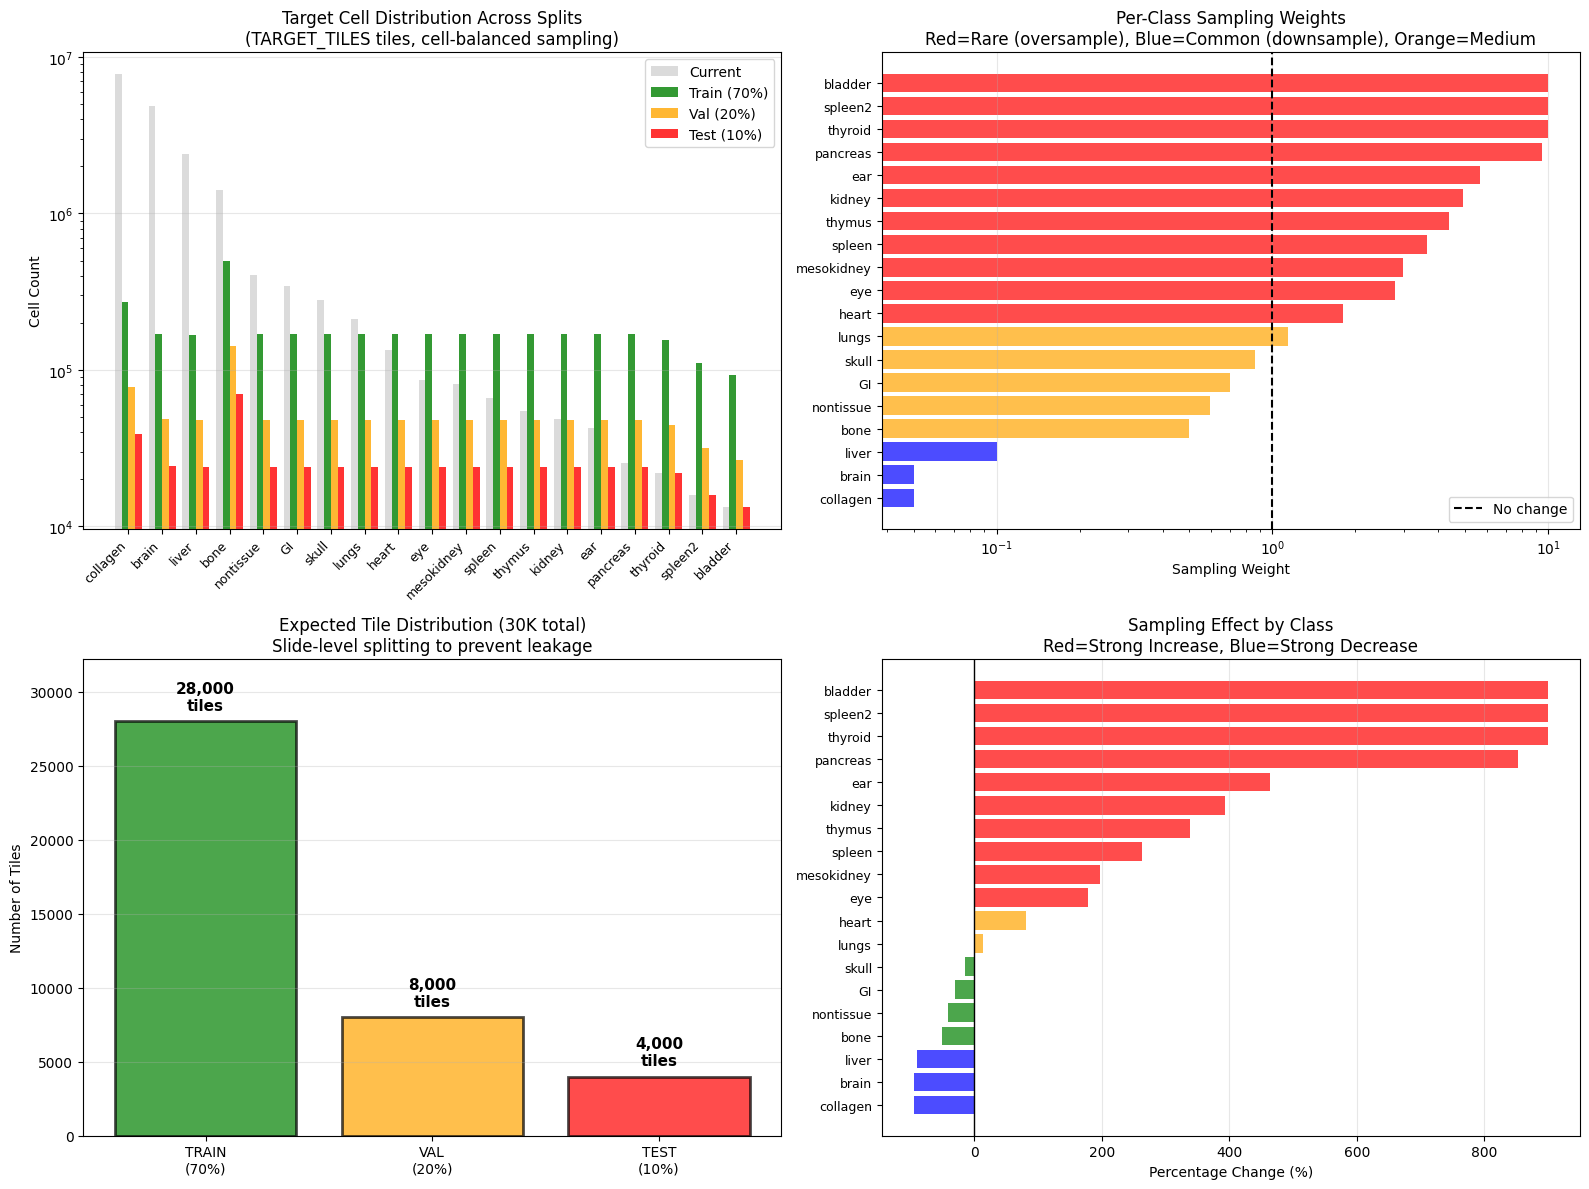


[SAVED] Visualization: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_224_40k\tile_level_30K_balanced_strategy.png


In [10]:
# %% SECTION 8: Visualization (UPDATED for TARGET_TILES tiles)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Use 30K target
TARGET_TILES_VIZ = TARGET_TILES
train_tiles_viz = int(TARGET_TILES_VIZ * PARAMS["train_ratio"])
val_tiles_viz = int(TARGET_TILES_VIZ * PARAMS["val_ratio"])
test_tiles_viz = TARGET_TILES_VIZ - train_tiles_viz - val_tiles_viz

# Panel 1: Current vs Target with splits
ax1 = axes[0, 0]
x = np.arange(len(class_totals))
width = 0.2

# Calculate split targets
train_targets = (hybrid_targets * PARAMS["train_ratio"]).astype(int)
val_targets = (hybrid_targets * PARAMS["val_ratio"]).astype(int)
test_targets = (hybrid_targets * PARAMS["test_ratio"]).astype(int)

ax1.bar(x - 1.5*width, class_totals.values, width, label='Current', alpha=0.8, color='lightgray')
ax1.bar(x - 0.5*width, train_targets.values, width, label='Train (70%)', alpha=0.8, color='green')
ax1.bar(x + 0.5*width, val_targets.values, width, label='Val (20%)', alpha=0.8, color='orange')
ax1.bar(x + 1.5*width, test_targets.values, width, label='Test (10%)', alpha=0.8, color='red')

ax1.set_xticks(x)
ax1.set_xticklabels(class_totals.index, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Cell Count')
ax1.set_title('Target Cell Distribution Across Splits\n(TARGET_TILES tiles, cell-balanced sampling)')
ax1.legend()
ax1.set_yscale('log')
ax1.grid(axis='y', alpha=0.3)

# Panel 2: Sampling weights by category
ax2 = axes[0, 1]

# Color by category
colors_weight = []
for cls in hybrid_weights.index:
    count = class_totals[cls]
    if count < rare_threshold_cells:
        colors_weight.append('red')  # Rare - oversample
    elif count > common_threshold_cells:
        colors_weight.append('blue')  # Common - downsample
    else:
        colors_weight.append('orange')  # Medium

bars = ax2.barh(range(len(hybrid_weights)), hybrid_weights.values, color=colors_weight, alpha=0.7)

ax2.set_yticks(range(len(hybrid_weights)))
ax2.set_yticklabels(hybrid_weights.index, fontsize=9)
ax2.set_xlabel('Sampling Weight')
ax2.set_title('Per-Class Sampling Weights\nRed=Rare (oversample), Blue=Common (downsample), Orange=Medium')
ax2.axvline(1.0, color='black', linestyle='--', linewidth=1.5, label='No change')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)
ax2.set_xscale('log')

# Panel 3: Expected tiles per split (30K total)
ax3 = axes[1, 0]
split_names = ['TRAIN\n(70%)', 'VAL\n(20%)', 'TEST\n(10%)']
split_counts = [train_tiles_viz, val_tiles_viz, test_tiles_viz]
colors_split = ['green', 'orange', 'red']

bars = ax3.bar(split_names, split_counts, color=colors_split, alpha=0.7, edgecolor='black', linewidth=2)

for bar, count in zip(bars, split_counts):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + max(split_counts)*0.02,
             f'{count:,}\ntiles',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

ax3.set_ylabel('Number of Tiles')
ax3.set_title(f'Expected Tile Distribution (30K total)\nSlide-level splitting to prevent leakage')
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim(0, max(split_counts) * 1.15)

# Panel 4: Weight effect visualization
ax4 = axes[1, 1]

# Show relative change for each class
changes = ((hybrid_targets - class_totals) / class_totals * 100).sort_values()

colors_change = ['red' if c > 100 else 'orange' if c > 0 else 'green' if c > -50 else 'blue'
                 for c in changes.values]

ax4.barh(range(len(changes)), changes.values, color=colors_change, alpha=0.7)
ax4.set_yticks(range(len(changes)))
ax4.set_yticklabels(changes.index, fontsize=9)
ax4.set_xlabel('Percentage Change (%)')
ax4.set_title('Sampling Effect by Class\nRed=Strong Increase, Blue=Strong Decrease')
ax4.axvline(0, color='black', linestyle='-', linewidth=1)
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "tile_level_30K_balanced_strategy.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n[SAVED] Visualization: {OUT_DIR / 'tile_level_30K_balanced_strategy.png'}")

In [11]:
# %% SECTION 9: Summary Report (UPDATED for {TARGET_TILES:,} tiles)
print("\n" + "="*70)
print("TILE-LEVEL CELL-BALANCED STRATEGY - SUMMARY")
print("="*70)

summary_text = f"""
DATASET CONFIGURATION ({TARGET_TILES:,} TILES):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Input Data:
  - Total slides: {len(manifest)}
  - Total cells: {class_totals.sum():,}
  - Total classes: {len(class_totals)}

Class Categories:
  - Rare classes: {len(rare_classes)} ({', '.join(rare_classes)})
  - Medium classes: {len(medium_classes)} ({', '.join(medium_classes)})
  - Common classes: {len(common_classes)} ({', '.join(common_classes)})

Sampling Strategy:
  - Target: {TARGET_TILES:,} tiles (instead of 168K)
  - Method: Cell-balanced per-class sampling
  - Rare → Oversample to reach target cells
  - Medium → Square root balancing
  - Common → Downsample to 30% of original

Expected Output:
  - Total tiles: ~{TARGET_TILES:,}
  - Train: ~{int(30000 * 0.7):,} tiles (70%)
  - Val: ~{int(30000 * 0.2):,} tiles (20%)
  - Test: ~{int(30000 * 0.1):,} tiles (10%)
  - Target cells: {hybrid_targets.sum():,} ({((hybrid_targets.sum() - class_totals.sum()) / class_totals.sum() * 100):.1f}% change)

Guarantees:
  - All {len(class_totals)} classes in all splits
  - Balanced cell counts per class
  - Slide-level splitting (no data leakage)
  - High-quality tiles prioritized via weighting

Tile Configuration:
  - Tile size: {PARAMS['tile_size']}×{PARAMS['tile_size']} pixels at 20x
  - MPP: {MPP_20X} µm/pixel
  - Physical size: {PARAMS['tile_size']*MPP_20X:.1f}×{PARAMS['tile_size']*MPP_20X:.1f} µm
  - Stride: {PARAMS['stride']} (non-overlapping)
  - Min cells/tile: {PARAMS['min_cells_per_tile']}

Training Efficiency:
  - Iterations/epoch: ~{int(30000 * 0.7) // 32:,}
  - Time/epoch: ~{(int(30000 * 0.7) // 32 * 0.5 / 60):.0f} minutes
  - 50 epochs: ~{(int(30000 * 0.7) // 32 * 0.5 / 3600) * 50:.1f} hours
  
  ✓ 4x faster than 168K tiles!
  ✓ Much faster iteration during development
  ✓ Sufficient data for fine-tuning pretrained CellViT

READY FOR IMPLEMENTATION!
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Next Steps:
  1. ✓ Parse GeoJSON annotations (Section 14)
  2. ✓ Generate tile candidates (Section 15)
  3. ▶ Cell-balanced tile selection (Section 16) ← YOU ARE HERE
  4. Assign to train/val/test splits (Section 17)
  5. Extract and save tiles (Section 18-19)
  6. Generate CellViT configs (Section 20)
"""

print(summary_text)
print("="*70)


TILE-LEVEL CELL-BALANCED STRATEGY - SUMMARY

DATASET CONFIGURATION (40,000 TILES):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Input Data:
  - Total slides: 48
  - Total cells: 18,289,085
  - Total classes: 19

Class Categories:
  - Rare classes: 11 (heart, eye, mesokidney, spleen, thymus, kidney, ear, pancreas, thyroid, spleen2, bladder)
  - Medium classes: 5 (bone, nontissue, GI, skull, lungs)
  - Common classes: 3 (collagen, brain, liver)

Sampling Strategy:
  - Target: 40,000 tiles (instead of 168K)
  - Method: Cell-balanced per-class sampling
  - Rare → Oversample to reach target cells
  - Medium → Square root balancing
  - Common → Downsample to 30% of original

Expected Output:
  - Total tiles: ~40,000
  - Train: ~21,000 tiles (70%)
  - Val: ~6,000 tiles (20%)
  - Test: ~3,000 tiles (10%)
  - Target cells: 4,984,956 (-72.7% change)

Guarantees:
  - All 19 classes in all splits
  - Balanced cell counts per class
  - Slide-level splitting (no data leak

In [12]:
# %% SECTION 11: Configuration for 20x Tile Extraction
import openslide
import cv2
import csv
import shutil
import yaml
from collections import defaultdict, Counter

print("Dependencies loaded")
# Your actual scan parameters
MPP_20X = 0.4416   # Actual MPP at 20x magnification
TILE_SIZE = PARAMS["tile_size"]   # 224 – matches ConvNeXt input
STRIDE = PARAMS["stride"]          # Non-overlapping
MIN_CELLS_PER_TILE = PARAMS["min_cells_per_tile"]

# Your class labels (already defined)
LABELS = [
    "bone", "brain", "eye", "heart", "lungs", "GI", "liver", "spleen", 
    "pancreas", "kidney", "mesokidney", "collagen", "ear", "nontissue", 
    "thymus", "thyroid", "bladder", "skull", "spleen2"
]

# Create label mapping
name_to_train = {name: i for i, name in enumerate(LABELS)}
train_to_name = {i: name for i, name in enumerate(LABELS)}

print(f"Working with {len(LABELS)} classes at MPP={MPP_20X}")
print(f"Tile size: {TILE_SIZE}x{TILE_SIZE} pixels = {TILE_SIZE*MPP_20X:.1f}x{TILE_SIZE*MPP_20X:.1f} µm")
print(f"Stride:    {STRIDE} px (non-overlapping)")
print(f"Min cells/tile: {MIN_CELLS_PER_TILE}")

print("Additional dependencies loaded for tile extraction")

# %% SECTION 12: Helper Functions for Tile Processing

def get_slide_mpp(slide: openslide.OpenSlide) -> float:
    """Extract MPP from slide, default to 20x if not found."""
    try:
        return float(slide.properties.get(openslide.PROPERTY_NAME_MPP_X, MPP_20X))
    except:
        return MPP_20X

def polygon_centroid(ring: list) -> tuple:
    """Get centroid of polygon."""
    if len(ring) < 3:
        return None, None
    xs, ys = zip(*[(p[0], p[1]) for p in ring])
    return sum(xs)/len(xs), sum(ys)/len(ys)

def assign_cells_to_tiles(cells_xy: np.ndarray, tile_size: int, stride: int) -> dict:
    """
    Assign cells to non-overlapping tile grid.
    
    Returns: {(tile_x, tile_y): [cell_indices]}
    """
    tiles = defaultdict(list)
    
    for idx, (x, y) in enumerate(cells_xy):
        tile_x = int(x // stride) * stride
        tile_y = int(y // stride) * stride
        
        # Check if cell is within tile bounds
        if tile_x <= x < tile_x + tile_size and tile_y <= y < tile_y + tile_size:
            tiles[(tile_x, tile_y)].append(idx)
    
    return tiles

print("Helper functions ready")

def read_ndpi_tile_resampled(
    slide: openslide.OpenSlide,
    x: int,
    y: int,
    tile_size: int,
    source_mpp: float,
    target_mpp: float
) -> np.ndarray:
    """
    Read and resample a tile from NDPI to target MPP.
    
    Args:
        slide: OpenSlide object
        x, y: Top-left coordinates at target resolution
        tile_size: Output tile size
        source_mpp: Source microns per pixel
        target_mpp: Target microns per pixel
    
    Returns:
        RGB numpy array of shape (tile_size, tile_size, 3)
    """
    scale = source_mpp / target_mpp
    
    # Calculate source coordinates and size
    x_src = int(x / scale)
    y_src = int(y / scale)
    size_src = int(np.ceil(tile_size / scale))
    
    # Read at level 0 (highest resolution)
    try:
        tile_pil = slide.read_region((x_src, y_src), 0, (size_src, size_src))
        tile_rgb = np.array(tile_pil.convert('RGB'))
        
        # Resize to target size if needed
        if tile_rgb.shape[0] != tile_size or tile_rgb.shape[1] != tile_size:
            tile_rgb = cv2.resize(tile_rgb, (tile_size, tile_size), interpolation=cv2.INTER_LINEAR)
        
        return tile_rgb
    except Exception as e:
        print(f"  Warning: Failed to read tile at ({x_src}, {y_src}): {e}")
        return np.zeros((tile_size, tile_size, 3), dtype=np.uint8)

print("Helper functions defined")

# %% SECTION 13: TileInfo Data Structure

@dataclass
class TileInfo:
    """Information about a candidate tile for extraction."""
    slide_id: str
    tile_idx: int
    grid_x: int
    grid_y: int
    x_coord: int
    y_coord: int
    cell_indices: List[int]
    class_counts: Counter = field(default_factory=Counter)
    assigned_split: str = None
    priority_score: float = 0.0
    
    @property
    def tile_id(self) -> str:
        """Generate unique tile identifier."""
        return f"{self.slide_id}_t{self.tile_idx}_{self.x_coord}_{self.y_coord}"
    
    @property
    def num_cells(self) -> int:
        """Total cells in this tile."""
        return len(self.cell_indices)
    
    def update_class_counts(self, labels: np.ndarray):
        """Update class counts from label array."""
        self.class_counts = Counter(labels[self.cell_indices].tolist())
    
    def calculate_priority(self, rare_classes: Set[int], target_weights: Dict[int, float]):
        """
        Calculate priority score for tile selection.
        Higher score = higher priority for inclusion.
        
        Priority based on:
        1. Presence of rare classes
        2. Class diversity
        3. Target sampling weights
        """
        score = 0.0
        
        # Bonus for rare classes
        rare_count = sum(self.class_counts[c] for c in rare_classes if c in self.class_counts)
        score += rare_count * 10.0
        
        # Bonus for diversity (number of unique classes)
        score += len(self.class_counts) * 2.0
        
        # Weighted by target sampling needs
        for cls, count in self.class_counts.items():
            weight = target_weights.get(cls, 1.0)
            score += count * weight
        
        self.priority_score = score
        return score

print("TileInfo dataclass defined")

Dependencies loaded
Working with 19 classes at MPP=0.4416
Tile size: 224x224 pixels = 98.9x98.9 µm
Stride:    224 px (non-overlapping)
Min cells/tile: 5
Additional dependencies loaded for tile extraction
Helper functions ready
Helper functions defined
TileInfo dataclass defined


In [13]:
# %% SECTION 14: Parse All GeoJSON Files and Collect Cell Information

print("\n" + "="*70)
print("PARSING GEOJSON ANNOTATIONS")
print("="*70)

# Load manifest
manifest = json.loads(MANIFEST_JSON.read_text(encoding="utf-8"))

# Store slide-level information
slide_data = {}

for entry in tqdm(manifest, desc="Parsing GeoJSON files"):
    slide_id = entry["slide_id"]
    geojson_path = Path(entry["geojson_path"])
    
    if not geojson_path.exists():
        print(f"  WARNING: Missing {geojson_path.name}")
        continue
    
    # Parse GeoJSON
    gj_raw = json.loads(geojson_path.read_text(encoding="utf-8"))
    
    # Handle both formats: {"features": [...]} or just [...]
    if isinstance(gj_raw, dict):
        features = gj_raw.get("features", [])
    elif isinstance(gj_raw, list):
        features = gj_raw
    else:
        print(f"  WARNING: Unexpected GeoJSON format for {slide_id}")
        continue
    
    centroids = []
    labels = []
    
    for feat in features:
        # Get class
        props = feat.get("properties", {})
        
        # Try different property paths (QuPath vs custom format)
        class_name = None
        if "classification" in props:
            class_name = props["classification"].get("name")
        elif "class" in props:
            class_name = props["class"]
        elif "name" in props:
            class_name = props["name"]
        
        if not class_name or class_name not in name_to_train:
            continue
        
        # Get centroid
        geom = feat.get("geometry", {})
        if geom.get("type") != "Polygon":
            continue
        
        coords = geom.get("coordinates", [[]])
        if not coords or len(coords) == 0:
            continue
            
        cx, cy = polygon_centroid(coords[0])
        if cx is None:
            continue
        
        centroids.append([cx, cy])
        labels.append(name_to_train[class_name])
    
    if centroids:
        slide_data[slide_id] = {
            "image_path": entry["image_path"],
            "geojson_path": str(geojson_path),
            "cells_xy": np.array(centroids, dtype=np.float32),
            "cells_labels": np.array(labels, dtype=np.int32),
            "num_cells": len(centroids)
        }

print(f"\n[SUMMARY] Parsed {len(slide_data)} slides with annotations")
total_cells_parsed = sum(data['num_cells'] for data in slide_data.values())
print(f"Total cells parsed: {total_cells_parsed:,}")

# Show first few slides
print("\nFirst few slides:")
for sid, data in list(slide_data.items())[:5]:
    print(f"  {sid}: {data['num_cells']:,} cells")


PARSING GEOJSON ANNOTATIONS


Parsing GeoJSON files:   0%|          | 0/48 [00:00<?, ?it/s]


[SUMMARY] Parsed 46 slides with annotations
Total cells parsed: 18,424,261

First few slides:
  monkey_fetus_40_0001: 11,650 cells
  monkey_fetus_40_0026: 73,684 cells
  monkey_fetus_40_0051: 97,541 cells
  monkey_fetus_40_0076: 135,176 cells
  monkey_fetus_40_0101: 177,587 cells


In [14]:
# Nontissue filter: exclude tiles where >75% of cells are nontissue
_NONTISSUE_ID = name_to_train.get("nontissue", -1)
_NONTISSUE_THRESH = 0.75

# %% SECTION 15: Generate Tile Candidates with Class-Based Sampling

print("\n" + "="*70)
print("GENERATING WEIGHTED TILE CANDIDATES")
print("="*70)

# Identify rare classes for prioritization
rare_class_ids = set(name_to_train[c] for c in LABELS 
                     if c in class_totals.index and (class_totals[c] / total_cells) < 0.01)

print(f"Rare classes (prioritized): {[train_to_name[i] for i in rare_class_ids]}")

# Generate tile candidates for each slide
all_tile_info = []

for slide_id, data in tqdm(slide_data.items(), desc="Generating tiles"):
    cells_xy = data["cells_xy"]
    cells_labels = data["cells_labels"]
    
    # Assign cells to tiles
    tile_groups = assign_cells_to_tiles(cells_xy, TILE_SIZE, STRIDE)
    
    # Filter by minimum cell count and create tile records
    for (tx, ty), cell_indices in tile_groups.items():
        if len(cell_indices) < MIN_CELLS_PER_TILE:
            continue

        # Skip near-pure nontissue tiles (no useful learning signal)
        _nt_frac = sum(1 for ci in cell_indices if cells_labels[ci]==_NONTISSUE_ID) / len(cell_indices)
        if _nt_frac > _NONTISSUE_THRESH:
            continue
        
        # Count classes in this tile
        tile_labels = cells_labels[cell_indices]
        class_counts = Counter(tile_labels.tolist())
        
        # Calculate tile weight based on our hybrid sampling strategy
        tile_weight = 0.0
        for cls_id, count in class_counts.items():
            cls_name = train_to_name[cls_id]
            if cls_name in hybrid_weights.index:
                tile_weight += count * hybrid_weights[cls_name]
        
        tile_weight /= len(cell_indices)  # Normalize by tile cell count
        
        # Bonus for rare classes
        if any(cls_id in rare_class_ids for cls_id in class_counts):
            tile_weight *= 2.0
        
        all_tile_info.append({
            "slide_id": slide_id,
            "tile_x": tx,
            "tile_y": ty,
            "cell_indices": cell_indices,
            "num_cells": len(cell_indices),
            "class_counts": class_counts,
            "weight": tile_weight
        })

print(f"\n[SUMMARY] Generated {len(all_tile_info):,} candidate tiles")
print(f"  Min cells/tile: {min(t['num_cells'] for t in all_tile_info)}")
print(f"  Max cells/tile: {max(t['num_cells'] for t in all_tile_info)}")
print(f"  Avg cells/tile: {np.mean([t['num_cells'] for t in all_tile_info]):.1f}")


GENERATING WEIGHTED TILE CANDIDATES
Rare classes (prioritized): ['eye', 'heart', 'spleen', 'pancreas', 'kidney', 'mesokidney', 'ear', 'thymus', 'thyroid', 'bladder', 'spleen2']


Generating tiles:   0%|          | 0/46 [00:00<?, ?it/s]


[SUMMARY] Generated 285,012 candidate tiles
  Min cells/tile: 5
  Max cells/tile: 394
  Avg cells/tile: 63.9


In [15]:
# %% SECTION 16 (OLD v5) — DISABLED
# This cell has been superseded by the redesigned Section 16 (cell id: ddaa3640).
# The old implementation used replace=True oversampling that embedded exact
# pixel-duplicate tiles directly into selected_tiles, causing downstream
# duplication of up to 17x for rare classes.
#
# The new Section 16 (below) selects TARGET_TILES *unique* tiles instead.
# Oversampling with augmentation is applied in Section 19 at extraction time.

print("⚠️  Old §16 (v5) is DISABLED — see redesigned §16 (ddaa3640) below.")


⚠️  Old §16 (v5) is DISABLED — see redesigned §16 (ddaa3640) below.



WEIGHTED UNIQUE TILE SELECTION (target: 40,000)
Valid candidate pool: 285,012 tiles
[DONE] Selected 40,000 unique tiles (target: 40,000)

Class             Original    Sampled    Mult    Tiles Category
----------------------------------------------------------------------
bone             1,415,191     59,163   0.04x    1,275 🔴 BIG5
brain            4,846,700    188,557   0.04x    2,931 🔴 BIG5
eye                 86,371     85,495   0.99x      986 🟢 RARE
heart              133,450    131,510   0.99x    3,456 🟡 MEDIUM
lungs              211,363    209,838   0.99x    2,432 🟡 MEDIUM
GI                 344,343    296,912   0.86x    5,112 🟡 MEDIUM
liver            2,385,118     93,742   0.04x    1,018 🔴 BIG5
spleen              66,377     66,190   1.00x      980 🟢 RARE
pancreas            25,307     25,283   1.00x      306 🟢 RARE
kidney              48,917     48,737   1.00x      565 🟢 RARE
mesokidney          81,261     80,388   0.99x    1,354 🟢 RARE
collagen         7,810,265    482,778 

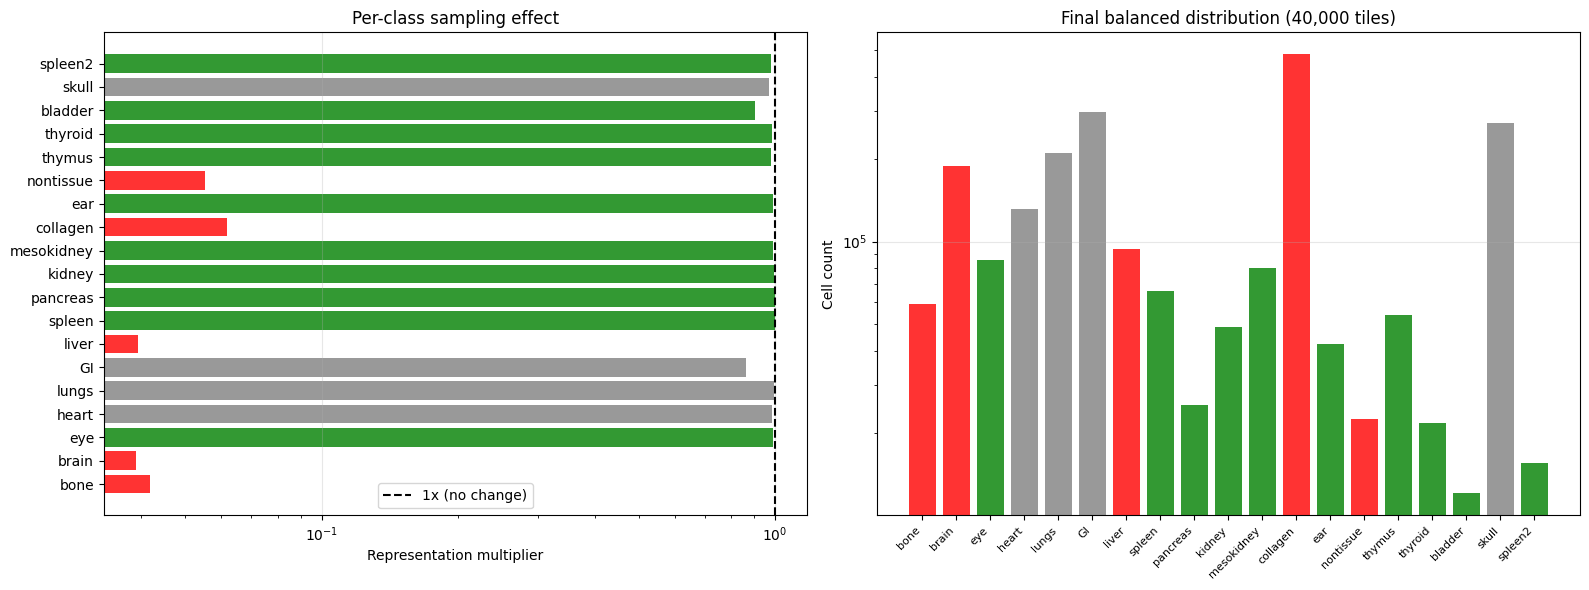

[SAVED] \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_224_40k\weighted_unique_selection.png


In [16]:
# %% SECTION 16: Weighted Unique Tile Selection (redesigned)
# Selects TARGET_TILES *unique* tiles. Oversampling is applied to the
# training split only in Section 17, keeping val/test duplication-free.

print("\n" + "="*70)
print(f"WEIGHTED UNIQUE TILE SELECTION (target: {TARGET_TILES:,})")
print("="*70)

BIG_5_NAMES = ["collagen", "bone", "brain", "liver", "nontissue"]
BIG_5_IDS   = {name_to_train[n] for n in BIG_5_NAMES if n in name_to_train}

RARE_CLASS_NAMES = ["kidney","pancreas","spleen","spleen2","thyroid",
                    "bladder","ear","eye","mesokidney","thymus"]
rare_class_ids = {name_to_train[n] for n in RARE_CLASS_NAMES if n in name_to_train}

# Per-tile weight calculation
valid_indices = []
tile_weights  = []

for idx, tile in enumerate(all_tile_info):
    tc = sum(tile["class_counts"].values())
    if tc == 0:
        continue
    value = 0.0
    for cls_id, cnt in tile["class_counts"].items():
        cname = train_to_name.get(cls_id, "")
        if cls_id in BIG_5_IDS:
            if cname == "collagen":    value += cnt * 0.01
            elif cname == "nontissue": value += cnt * 0.02
            else:                      value += cnt * 0.03
        elif cls_id in rare_class_ids:
            value += cnt * 10.0   # strong boost
        else:
            value += cnt * 1.0
    value /= tc
    # Extra BIG5 dominance penalty
    b5 = sum(tile["class_counts"].get(b,0) for b in BIG_5_IDS)
    if b5/tc > 0.6:   value *= 0.01
    elif b5/tc > 0.4: value *= 0.05
    valid_indices.append(idx)
    tile_weights.append(value)

tile_weights = np.array(tile_weights, dtype=float)
tile_weights = np.maximum(tile_weights, 1e-10)
tile_probs   = tile_weights / tile_weights.sum()

print(f"Valid candidate pool: {len(valid_indices):,} tiles")

# Sample TARGET_TILES unique tiles (replace=False  → no duplicates)
np.random.seed(PARAMS["seed"])
n_sample = min(TARGET_TILES, len(valid_indices))
sel_arr  = np.random.choice(valid_indices, size=n_sample, replace=False, p=tile_probs)
selected_tiles = [all_tile_info[i] for i in sel_arr]

print(f"[DONE] Selected {len(selected_tiles):,} unique tiles (target: {TARGET_TILES:,})")

# ── Distribution report ──
sampled_class_counts = Counter()
tiles_per_class = Counter()
for tile in selected_tiles:
    sampled_class_counts.update(tile["class_counts"])
    for cls_id in tile["class_counts"]:
        tiles_per_class[cls_id] += 1

print(f"\n{'Class':<15} {'Original':>10} {'Sampled':>10} {'Mult':>7} {'Tiles':>8} {'Category'}")
print("-"*70)
for cls_name in LABELS:
    cls_id = name_to_train[cls_name]
    orig  = class_totals[cls_name]
    samp  = sampled_class_counts.get(cls_id, 0)
    mult  = samp/orig if orig>0 else 0
    n_til = tiles_per_class.get(cls_id, 0)
    cat   = "🔴 BIG5" if cls_id in BIG_5_IDS else ("🟢 RARE" if cls_id in rare_class_ids else "🟡 MEDIUM")
    print(f"{cls_name:<15} {orig:>10,} {samp:>10,} {mult:>6.2f}x {n_til:>8,} {cat}")

counts_list = [sampled_class_counts.get(name_to_train[c],1) for c in LABELS]
print(f"\nMax/Min ratio: {max(counts_list)/min(counts_list):.1f}x")

# Visualisation
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ["red" if name_to_train[n] in BIG_5_IDS else
          "green" if name_to_train[n] in rare_class_ids else "gray"
          for n in LABELS]

mults = [sampled_class_counts.get(name_to_train[n],0)/class_totals[n]
         if class_totals[n]>0 else 0 for n in LABELS]
axes[0].barh(LABELS, mults, color=colors, alpha=0.8)
axes[0].axvline(1.0, color="black", linestyle="--", label="1x (no change)")
axes[0].set_xlabel("Representation multiplier"); axes[0].set_title("Per-class sampling effect")
axes[0].legend(); axes[0].grid(axis="x", alpha=0.3); axes[0].set_xscale("log")

final_counts = [sampled_class_counts.get(name_to_train[n],1) for n in LABELS]
axes[1].bar(LABELS, final_counts, color=colors, alpha=0.8)
axes[1].set_xticks(range(len(LABELS)))
axes[1].set_xticklabels(LABELS, rotation=45, ha="right", fontsize=8)
axes[1].set_yscale("log"); axes[1].set_ylabel("Cell count")
axes[1].set_title(f"Final balanced distribution ({len(selected_tiles):,} tiles)")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "weighted_unique_selection.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"[SAVED] {OUT_DIR / 'weighted_unique_selection.png'}")


In [17]:
# %% SECTION 17: Force-Balanced Stratified Split + Training Oversampling
# Phase 1: slide-level split (guarantees rare classes in all splits)
# Phase 2: oversample rare classes WITHIN train only (_dup{k} suffix)
# Val and Test remain purely unique tiles – no data leakage.

print("\n" + "="*70)
print("FORCE-BALANCED STRATIFIED SPLIT")
print("="*70)

tiles_by_slide = defaultdict(list)
for tile in selected_tiles:
    tiles_by_slide[tile["slide_id"]].append(tile)

slide_info = {}
for slide_id, tiles in tiles_by_slide.items():
    sc = Counter()
    for t in tiles: sc.update(t["class_counts"])
    slide_info[slide_id] = {
        "n_tiles": len(tiles), "n_cells": sum(sc.values()),
        "class_counts": sc, "classes_present": set(sc.keys()), "tiles": tiles
    }

class_to_slides = defaultdict(list)
for slide_id, info in slide_info.items():
    for cls_id in info["classes_present"]:
        class_to_slides[cls_id].append(slide_id)

np.random.seed(PARAMS["seed"])
train_slides, val_slides, test_slides = [], [], []
train_cc, val_cc, test_cc = Counter(), Counter(), Counter()

total_tiles_count = len(selected_tiles)
target_train = int(total_tiles_count * PARAMS["train_ratio"])
target_val   = int(total_tiles_count * PARAMS["val_ratio"])
target_test  = total_tiles_count - target_train - target_val

# ── Phase 1: guarantee rare classes in all splits ──
rare_slide_threshold = 10
rare_classes_map = {
    cls_id: class_to_slides[cls_id]
    for cls_id in range(len(LABELS))
    if len(class_to_slides[cls_id]) <= rare_slide_threshold
}

print(f"\nPhase 1: distributing rare classes across splits...")
assigned = set()
for cls_id, slides_with in rare_classes_map.items():
    available = [s for s in slides_with if s not in assigned]
    if len(available) >= 3:
        available.sort(key=lambda s: slide_info[s]["n_tiles"])
        tr, va, te = available[0], available[len(available)//2], available[-1]
        train_slides.append(tr); val_slides.append(va); test_slides.append(te)
        assigned.update([tr, va, te])
        train_cc.update(slide_info[tr]["class_counts"])
        val_cc.update(slide_info[va]["class_counts"])
        test_cc.update(slide_info[te]["class_counts"])
        print(f"  {train_to_name[cls_id]:12s}: assigned to all splits")
    elif len(available) == 2:
        train_slides.append(available[0]); val_slides.append(available[1])
        assigned.update(available)
        train_cc.update(slide_info[available[0]]["class_counts"])
        val_cc.update(slide_info[available[1]]["class_counts"])
        print(f"  {train_to_name[cls_id]:12s}: ⚠️  only 2 slides – TEST will miss this class")
    elif len(available) == 1:
        train_slides.append(available[0]); assigned.add(available[0])
        train_cc.update(slide_info[available[0]]["class_counts"])
        print(f"  {train_to_name[cls_id]:12s}: ⚠️  only 1 slide – VAL/TEST will miss this class")

# ── Phase 2: balance tile counts with remaining slides ──
print(f"\nPhase 2: balancing tile counts...")
remaining = sorted(
    [s for s in slide_info if s not in assigned],
    key=lambda s: slide_info[s]["n_tiles"], reverse=True
)
for slide_id in remaining:
    info = slide_info[slide_id]
    tr_cnt = sum(slide_info[s]["n_tiles"] for s in train_slides)
    va_cnt = sum(slide_info[s]["n_tiles"] for s in val_slides)
    te_cnt = sum(slide_info[s]["n_tiles"] for s in test_slides)
    tr_def = target_train - tr_cnt
    va_def = target_val   - va_cnt
    te_def = target_test  - te_cnt
    if tr_def >= va_def and tr_def >= te_def:
        train_slides.append(slide_id); train_cc.update(info["class_counts"])
    elif va_def >= te_def:
        val_slides.append(slide_id);   val_cc.update(info["class_counts"])
    else:
        test_slides.append(slide_id);  test_cc.update(info["class_counts"])

# ── Assign tiles to splits ──
train_tiles_unique, val_tiles, test_tiles = [], [], []
for tile in selected_tiles:
    if   tile["slide_id"] in train_slides: train_tiles_unique.append(tile)
    elif tile["slide_id"] in val_slides:   val_tiles.append(tile)
    else:                                  test_tiles.append(tile)

tr_u = sum(slide_info[s]["n_tiles"] for s in train_slides)
va_u = sum(slide_info[s]["n_tiles"] for s in val_slides)
te_u = sum(slide_info[s]["n_tiles"] for s in test_slides)
print(f"\nSlide assignment:")
print(f"  TRAIN: {len(train_slides)} slides → {tr_u:,} unique tiles ({tr_u/total_tiles_count*100:.1f}%)")
print(f"  VAL:   {len(val_slides)} slides → {va_u:,} unique tiles ({va_u/total_tiles_count*100:.1f}%)")
print(f"  TEST:  {len(test_slides)} slides → {te_u:,} unique tiles ({te_u/total_tiles_count*100:.1f}%)")

# ── Phase 3: oversample rare classes WITHIN training set only ──
print("\n" + "="*70)
print("OVERSAMPLING RARE CLASSES (TRAIN ONLY, with _dup{{k}} suffix)")
print("="*70)

TRAIN_OVERSAMPLE_TARGETS = {
    "kidney":     2500,
    "pancreas":   2000,
    "bladder":    2500,
    "spleen":     1500,
    "spleen2":    1200,
    "thyroid":    2000,
    "ear":        1500,
    "eye":        1200,
    "mesokidney": 1500,
    "thymus":     1500,
}

# Build lookup: class → train tiles containing that class
train_tiles_by_cls = defaultdict(list)
for tile in train_tiles_unique:
    for cls_id in tile["class_counts"]:
        train_tiles_by_cls[cls_id].append(tile)

oversampled_extras = []
np.random.seed(PARAMS["seed"] + 1)

print(f"\n{'Class':<13} {'Available':>10} {'Target':>8} {'Added':>8} {'Mult':>6}")
print("-"*50)
for cls_name, tgt in TRAIN_OVERSAMPLE_TARGETS.items():
    cls_id    = name_to_train[cls_name]
    available = train_tiles_by_cls.get(cls_id, [])
    n_avail   = len(available)
    if n_avail == 0:
        print(f"  {cls_name:<11} ⚠️  no tiles in training set – skipping")
        continue
    if n_avail >= tgt:
        print(f"  {cls_name:<11} {n_avail:>10,} {tgt:>8,} {0:>8} (no oversampling needed)")
        continue
        
    # Cap target to max 8x available (so we don't exceed 8 unique augmented variants)
    max_tgt = n_avail * 8
    if tgt > max_tgt:
        print(f"  {cls_name:<11} ⚠️  Capping target from {tgt} to {max_tgt} (max 8x augmentation)")
        tgt = max_tgt
        
    n_add  = tgt - n_avail
    chosen = np.random.choice(len(available), size=n_add, replace=True)
    dup_ctr = {}
    for orig_idx in chosen:
        orig    = available[orig_idx]
        k       = dup_ctr.get(orig_idx, 0) + 1
        dup_ctr[orig_idx] = k
        dup_tile = dict(orig)
        dup_tile["dup_suffix"] = f"_dup{k}"
        oversampled_extras.append(dup_tile)
    mult = tgt / n_avail
    print(f"  {cls_name:<11} {n_avail:>10,} {tgt:>8,} {n_add:>8,} {mult:>5.1f}x")

train_tiles = train_tiles_unique + oversampled_extras

# ── Assign split labels ──
for t in train_tiles: t["split"] = "train"
for t in val_tiles:   t["split"] = "val"
for t in test_tiles:  t["split"] = "test"

print(f"\nFinal tile counts:")
print(f"  TRAIN: {len(train_tiles_unique):,} unique + {len(oversampled_extras):,} oversampled = {len(train_tiles):,} total")
print(f"  VAL:   {len(val_tiles):,} (unique only)")
print(f"  TEST:  {len(test_tiles):,} (unique only)")
print(f"  TOTAL: {len(train_tiles)+len(val_tiles)+len(test_tiles):,}")

# Class coverage check
from scipy.spatial.distance import jensenshannon
train_cls = set(c for t in train_tiles for c in t["class_counts"])
val_cls   = set(c for t in val_tiles   for c in t["class_counts"])
test_cls  = set(c for t in test_tiles  for c in t["class_counts"])
print(f"\nClass coverage: TRAIN {len(train_cls)}/{len(LABELS)} | VAL {len(val_cls)}/{len(LABELS)} | TEST {len(test_cls)}/{len(LABELS)}")
for split_name, s_cls in [("TRAIN", train_cls), ("VAL", val_cls), ("TEST", test_cls)]:
    missing = set(range(len(LABELS))) - s_cls
    if missing: print(f"  ⚠️  {split_name} missing: {[train_to_name[x] for x in missing]}")



FORCE-BALANCED STRATIFIED SPLIT

Phase 1: distributing rare classes across splits...

Phase 2: balancing tile counts...

Slide assignment:
  TRAIN: 24 slides → 27,999 unique tiles (70.0%)
  VAL:   14 slides → 8,006 unique tiles (20.0%)
  TEST:  8 slides → 3,995 unique tiles (10.0%)

OVERSAMPLING RARE CLASSES (TRAIN ONLY, with _dup{{k}} suffix)

Class          Available   Target    Added   Mult
--------------------------------------------------
  kidney             446    2,500    2,054   5.6x
  pancreas    ⚠️  Capping target from 2000 to 1640 (max 8x augmentation)
  pancreas           205    1,640    1,435   8.0x
  bladder          1,172    2,500    1,328   2.1x
  spleen             808    1,500      692   1.9x
  spleen2            164    1,200    1,036   7.3x
  thyroid            400    2,000    1,600   5.0x
  ear                511    1,500      989   2.9x
  eye                446    1,200      754   2.7x
  mesokidney         972    1,500      528   1.5x
  thymus             789    

In [ ]:
# %% SECTION 17.5: Diagnostic Visualization: H&E + Nuclear Centroids
import openslide
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

print('\n' + '='*70)
print('DIAGNOSTIC VISUALIZATION')
print('='*70)

# Select a sample slide from the training set
sample_slide = train_slides[0]
sample_data = slide_data[sample_slide]
image_path = sample_data['image_path']
cells_xy = sample_data['cells_xy']
cells_lbl = sample_data['cells_labels']

print(f'Visualizing slide: {sample_slide}')
print(f'Path: {image_path}')

# Open slide
slide = openslide.OpenSlide(image_path)

# Pick a region from the selected tiles to ensure we have tissue and cells
slide_sample_tiles = [t for t in selected_tiles if t['slide_id'] == sample_slide]
if slide_sample_tiles:
    # Pick a tile in the middle of the sample set
    target_tile = slide_sample_tiles[len(slide_sample_tiles)//2]
    tx, ty = target_tile['tile_x'], target_tile['tile_y']
else:
    # Fallback to a fixed coordinate if no tiles found (unlikely)
    tx, ty = 10000, 10000

roi_size = 2048
print(f'Extracting ROI at ({tx}, {ty}) size {roi_size}x{roi_size}')

# Read ROI
roi_img = slide.read_region((tx, ty), 0, (roi_size, roi_size)).convert('RGB')
roi_img = np.array(roi_img)

# Filter cells within ROI
mask = (cells_xy[:,0] >= tx) & (cells_xy[:,0] < tx+roi_size) & \
       (cells_xy[:,1] >= ty) & (cells_xy[:,1] < ty+roi_size)
roi_cells_xy = cells_xy[mask]
roi_cells_lbl = cells_lbl[mask]

# Localize coordinates to ROI
roi_cells_xy_local = roi_cells_xy - np.array([tx, ty])

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# 1. Pure H&E
axes[0].imshow(roi_img)
axes[0].set_title('Raw H&E Region')
axes[0].axis('off')

# 2. Overlay
axes[1].imshow(roi_img)
for i in range(len(roi_cells_xy_local)):
    cls_id = int(roi_cells_lbl[i])
    color = np.array(COLORS[cls_id])/255.0
    axes[1].scatter(roi_cells_xy_local[i, 0], roi_cells_xy_local[i, 1], c=[color], s=2)
axes[1].set_title('H&E + Color-coded Centroids')
axes[1].axis('off')

# 3. Zoom
zoom_size = 512
zc = roi_size // 2
z_start = zc - zoom_size // 2
z_end = zc + zoom_size // 2
axes[2].imshow(roi_img[z_start:z_end, z_start:z_end])

z_mask = (roi_cells_xy_local[:,0] >= z_start) & (roi_cells_xy_local[:,0] < z_end) & \
         (roi_cells_xy_local[:,1] >= z_start) & (roi_cells_xy_local[:,1] < z_end)
z_xy = roi_cells_xy_local[z_mask] - np.array([z_start, z_start])
z_lbl = roi_cells_lbl[z_mask]
for i in range(len(z_xy)):
    cls_id = int(z_lbl[i])
    color = np.array(COLORS[cls_id])/255.0
    axes[2].scatter(z_xy[i, 0], z_xy[i, 1], c=[color], s=15, edgecolors='white', linewidths=0.5)
axes[2].set_title('Zoom Window (Alignment Check)')
axes[2].axis('off')

# Add a legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=LABELS[i], 
           markerfacecolor=np.array(COLORS[i])/255.0, markersize=8)
    for i in range(len(LABELS))
]
fig.legend(handles=legend_elements, loc='lower center', ncol=7, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

print('Diagnostic visualization complete. Please verify centroid centering on nuclei.')


In [23]:
# %% SECTION 18: Create Output Directory Structure

print("\n" + "="*70)
print("CREATING OUTPUT DIRECTORY STRUCTURE")
print("="*70)

# Define output paths
# OUT_BASE = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\data_for_cellvit_GS40_balanced")
OUT_BASE = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_256_40k_48_slides")

# Create directory structure
images_dir = OUT_BASE / "train" / "images"
labels_dir = OUT_BASE / "train" / "labels"
splits_dir = OUT_BASE / "splits"

for d in [images_dir, labels_dir, splits_dir]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {OUT_BASE}")
print(f"  Images: {images_dir}")
print(f"  Labels: {labels_dir}")
print(f"  Splits: {splits_dir}")

# Save label map so consumers know integer class → name mapping
label_map_path = OUT_BASE / "label_map.json"
with label_map_path.open("w") as f:
    json.dump({str(k): v for k, v in train_to_name.items()}, f, indent=2)
print(f"[SAVED] {label_map_path}")



CREATING OUTPUT DIRECTORY STRUCTURE
Output directory: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_224_40k_48_slides
  Images: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_224_40k_48_slides\train\images
  Labels: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_224_40k_48_slides\train\labels
  Splits: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_224_40k_48_slides\splits
[SAVED] \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_224_40k_48_slides\label_map.json


In [24]:
# %% SECTION 19: Extract and Save Tiles (AUGMENTED DUPLICATES)
# • OpenSlide opened once per slide (not once per tile)
# • Tiles resized to TILE_SIZE×TILE_SIZE after reading
# • Duplicate tiles (_dup{k}) receive deterministic geometric augmentation
#   so no two saved PNGs are byte-identical (up to 8 distinct variants)
# • CSV label files are coordinate-transformed to match each augmentation
# • CSV label files include a header row

import re as _re

# ── Augmentation helpers ──────────────────────────────────────────────────────

def _augment_image(img, aug_id):
    """Apply one of 8 geometric augmentations to a H×W×3 ndarray."""
    if aug_id == 0: return img
    if aug_id == 1: return img[:, ::-1, :].copy()           # hflip
    if aug_id == 2: return img[::-1, :, :].copy()           # vflip
    if aug_id == 3: return np.rot90(img, k=1).copy()        # 90° CCW
    if aug_id == 4: return np.rot90(img, k=2).copy()        # 180°
    if aug_id == 5: return np.rot90(img, k=3).copy()        # 270° CCW
    if aug_id == 6: return img[::-1, ::-1, :].copy()        # hflip + vflip
    if aug_id == 7: return np.rot90(img[:, ::-1, :], k=1).copy()  # hflip + 90° CCW
    return img

def _augment_coords(x, y, aug_id, S):
    """Transform cell local coords (x, y) for augmentation aug_id.
    S = tile_size - 1 (max valid coordinate).
    """
    if aug_id == 0: return x, y
    if aug_id == 1: return S - x, y
    if aug_id == 2: return x,     S - y
    if aug_id == 3: return y,     S - x
    if aug_id == 4: return S - x, S - y
    if aug_id == 5: return S - y, x
    if aug_id == 6: return S - x, S - y
    if aug_id == 7: return y,     x
    return x, y

_AUG_S = TILE_SIZE - 1  # max coordinate value

# ── Extraction loop ───────────────────────────────────────────────────────────

print("\n" + "="*70)
print("EXTRACTING AND SAVING TILES (with augmented duplicates)")
print("="*70)

all_output_tiles = train_tiles + val_tiles + test_tiles

from collections import defaultdict as _dd
tiles_by_slide_out = _dd(list)
for tile in all_output_tiles:
    tiles_by_slide_out[tile["slide_id"]].append(tile)

print(f"Processing {len(tiles_by_slide_out)} slides, {len(all_output_tiles):,} tiles total")

tile_records = []
failed_tiles = []
aug_counts   = [0] * 8   # how many tiles used each augmentation variant

for slide_id, slide_tiles in tqdm(tiles_by_slide_out.items(), desc="Slides"):
    image_path = slide_data[slide_id]["image_path"]
    cells_xy   = slide_data[slide_id]["cells_xy"]
    cells_lbl  = slide_data[slide_id]["cells_labels"]

    try:
        slide = openslide.OpenSlide(image_path)
    except Exception as e:
        print(f"\n  ERROR opening {slide_id}: {e}")
        for tile in slide_tiles:
            failed_tiles.append((f"{slide_id}_{tile['tile_x']}_{tile['tile_y']}", str(e)))
        continue

    for tile in slide_tiles:
        dup_suffix = tile.get("dup_suffix", "")
        tile_id    = f"{slide_id}_x{tile['tile_x']}_y{tile['tile_y']}{dup_suffix}"

        # Determine augmentation variant for this tile
        if dup_suffix:
            # parse the integer k from "_dup{k}"
            _m = _re.search(r"_dup(\d+)$", dup_suffix)
            _k = int(_m.group(1)) if _m else 0
            aug_id = _k % 8
        else:
            aug_id = 0  # originals: no augmentation

        try:
            # Read at level 0 (native 20x), resize to TILE_SIZE×TILE_SIZE
            tile_pil = slide.read_region(
                (tile["tile_x"], tile["tile_y"]), 0, (TILE_SIZE, TILE_SIZE)
            )
            tile_rgb = np.array(tile_pil.convert("RGB"))
            if tile_rgb.shape[0] != TILE_SIZE or tile_rgb.shape[1] != TILE_SIZE:
                tile_rgb = cv2.resize(tile_rgb, (TILE_SIZE, TILE_SIZE),
                                      interpolation=cv2.INTER_LINEAR)

            # Apply geometric augmentation
            tile_rgb = _augment_image(tile_rgb, aug_id)
            aug_counts[aug_id] += 1

            # Save PNG
            cv2.imwrite(
                str(images_dir / f"{tile_id}.png"),
                cv2.cvtColor(tile_rgb, cv2.COLOR_RGB2BGR)
            )

            # Save CSV labels with header + transformed coordinates
            with (labels_dir / f"{tile_id}.csv").open("w", newline="") as fh:
                writer = csv.writer(fh)
                writer.writerow(["x_local", "y_local", "class_id"])
                for idx in tile["cell_indices"]:
                    x_raw = int(cells_xy[idx, 0] - tile["tile_x"])
                    y_raw = int(cells_xy[idx, 1] - tile["tile_y"])
                    x_aug, y_aug = _augment_coords(x_raw, y_raw, aug_id, _AUG_S)
                    writer.writerow([x_aug, y_aug, int(cells_lbl[idx])])

            tile_records.append({
                "tile_id":      tile_id,
                "slide_id":     slide_id,
                "split":        tile["split"],
                "num_cells":    tile["num_cells"],
                "is_duplicate": bool(dup_suffix),
                "aug_id":       aug_id,
            })

        except Exception as e:
            failed_tiles.append((tile_id, str(e)))

    slide.close()

n_ok   = len(tile_records)
n_dup  = sum(1 for r in tile_records if r["is_duplicate"])
n_uniq = n_ok - n_dup
print(f"\n[DONE] Saved {n_ok:,} tiles  ({n_uniq:,} unique + {n_dup:,} augmented duplicates)")
print("\nAugmentation variant breakdown:")
aug_names = ["0-identity","1-hflip","2-vflip","3-rot90","4-rot180","5-rot270","6-hvflip","7-hflip+rot90"]
for aid, cnt in enumerate(aug_counts):
    print(f"  {aug_names[aid]:20s}: {cnt:,}")
if failed_tiles:
    print(f"  Failed: {len(failed_tiles)}")
    for tid, err in failed_tiles[:5]:
        print(f"    {tid}: {err}")



EXTRACTING AND SAVING TILES (with augmented duplicates)
Processing 46 slides, 51,127 tiles total


Slides:   0%|          | 0/46 [00:00<?, ?it/s]


[DONE] Saved 51,127 tiles  (40,000 unique + 11,127 augmented duplicates)

Augmentation variant breakdown:
  0-identity          : 40,195
  1-hflip             : 4,276
  2-vflip             : 2,544
  3-rot90             : 1,556
  4-rot180            : 1,043
  5-rot270            : 723
  6-hvflip            : 485
  7-hflip+rot90       : 305


In [25]:
# %% SECTION 20: Configurable K-Fold Cross-Validation

print("\n" + "="*70)
print("CONFIGURABLE K-FOLD CROSS-VALIDATION SETUP")
print("="*70)

# ============================================================================
# CONFIGURATION: Set your desired number of folds here
# ============================================================================

N_FOLDS = 1  # ← CHANGE THIS: Options: 1, 3, 5, 7, 10, etc.
             # N_FOLDS = 1 → Single train/val split (no cross-validation)
             # N_FOLDS = 5 → 5-fold cross-validation (recommended)
             # N_FOLDS = 10 → 10-fold cross-validation (more robust, slower)

# ============================================================================

print(f"\n🎯 Configuration: {N_FOLDS}-fold cross-validation")

if N_FOLDS == 1:
    print("   Note: N_FOLDS=1 means single train/val split (no cross-validation)")
elif N_FOLDS < 3:
    print("   ⚠️  Warning: N_FOLDS < 3 may not provide robust estimates")
elif N_FOLDS > 10:
    print(f"   ⚠️  Warning: {N_FOLDS} folds will require {N_FOLDS}x training time")

# Save tile records
df = pd.DataFrame(tile_records)

# Separate test set (always fixed, never used in training)
test_df = df[df["split"] == "test"]
test_ids = test_df["tile_id"].tolist()
test_slides = test_df["slide_id"].unique().tolist()

print(f"\n📊 Dataset splits:")
print(f"  Test set (fixed): {len(test_ids):,} tiles from {len(test_slides)} slides")

# Get development set (train + val slides for cross-validation)
dev_df = df[df["split"].isin(["train", "val"])]
dev_slides = dev_df["slide_id"].unique().tolist()

print(f"  Development set: {len(dev_df):,} tiles from {len(dev_slides)} slides")

# Validate fold configuration
if N_FOLDS > len(dev_slides):
    print(f"\n❌ ERROR: N_FOLDS ({N_FOLDS}) cannot exceed number of dev slides ({len(dev_slides)})")
    print(f"   Maximum folds possible: {len(dev_slides)}")
    print(f"   Recommended: Use N_FOLDS <= {len(dev_slides) // 2}")
    raise ValueError(f"N_FOLDS ({N_FOLDS}) > available slides ({len(dev_slides)})")

if N_FOLDS > len(dev_slides) // 2:
    print(f"   ⚠️  Warning: N_FOLDS={N_FOLDS} with {len(dev_slides)} slides means very small validation sets")

# Shuffle dev slides for random fold assignment
np.random.seed(PARAMS["seed"])
dev_slides_shuffled = dev_slides.copy()
np.random.shuffle(dev_slides_shuffled)

print(f"\n🔄 Creating {'single split' if N_FOLDS == 1 else f'{N_FOLDS}-fold cross-validation'}...")

# Create splits directory
splits_dir.mkdir(parents=True, exist_ok=True)

# Save fixed test split (same for all folds/configs)
pd.DataFrame(test_ids).to_csv(splits_dir / "test.csv", index=False, header=False)
print(f"\n✓ Saved: {splits_dir / 'test.csv'}")

# Tracking statistics
fold_stats = []

# Special case: N_FOLDS = 1 (single split, use your original train/val)
if N_FOLDS == 1:
    print("\n--- Single Split (No Cross-Validation) ---")
    
    # Use your original stratified split
    train_ids_single = df[df["split"] == "train"]["tile_id"].tolist()
    val_ids_single = df[df["split"] == "val"]["tile_id"].tolist()
    train_slides_single = df[df["split"] == "train"]["slide_id"].unique().tolist()
    val_slides_single = df[df["split"] == "val"]["slide_id"].unique().tolist()
    
    print(f"  Train: {len(train_ids_single):,} tiles from {len(train_slides_single)} slides")
    print(f"  Val:   {len(val_ids_single):,} tiles from {len(val_slides_single)} slides")
    print(f"  Test:  {len(test_ids):,} tiles from {len(test_slides)} slides")
    
    # Save single split
    fold_dir = splits_dir / "fold_0"
    fold_dir.mkdir(parents=True, exist_ok=True)
    
    pd.DataFrame(train_ids_single).to_csv(fold_dir / "train.csv", index=False, header=False)
    pd.DataFrame(val_ids_single).to_csv(fold_dir / "val.csv", index=False, header=False)
    
    # Create single config
    config = {
        "logging": {
            "mode": "online",
            "project": "cellvit_GS40_balanced",
            "log_comment": "single_split_20x_oversampled"
        },
        "data": {
            "dataset_path": str(OUT_BASE),
            "num_classes": len(LABELS),
            "train_filelist": str(fold_dir / "train.csv"),
            "val_filelist": str(fold_dir / "val.csv"),
            "test_filelist": str(splits_dir / "test.csv"),
            "label_map": train_to_name
        },
        "cellvit_path": r"\\kittyserverdw\Andre_kit\data\students\Diogo\codes\CellViT_plus_plus\checkpoints\CellViT-256-x40-AMP.pth",
        "training": {
            "batch_size": 32,
            "epochs": 50,
            "learning_rate": 0.0001,
            "fold": 0
        }
    }
    
    config_dir = OUT_BASE / "train_configs" / "ViT256"
    config_dir.mkdir(parents=True, exist_ok=True)
    
    config_path = config_dir / "train_config.yaml"
    with config_path.open("w") as f:
        yaml.safe_dump(config, f)
    
    fold_stats.append({
        "fold": 0,
        "train_tiles": len(train_ids_single),
        "val_tiles": len(val_ids_single),
        "train_slides": len(train_slides_single),
        "val_slides": len(val_slides_single),
        "config": "train_config.yaml"
    })
    
    print(f"\n✓ Saved: {config_path}")

# Standard case: N_FOLDS >= 2 (cross-validation)
else:
    print("")
    for fold in range(N_FOLDS):
        print(f"--- Fold {fold + 1}/{N_FOLDS} ---")
        
        # K-fold split: every N_FOLDS-th slide goes to validation
        val_slides_fold = dev_slides_shuffled[fold::N_FOLDS]
        train_slides_fold = [s for s in dev_slides_shuffled if s not in val_slides_fold]
        
        # Get tile IDs for this fold
        train_ids_fold = dev_df[dev_df["slide_id"].isin(train_slides_fold)]["tile_id"].tolist()
        val_ids_fold = dev_df[dev_df["slide_id"].isin(val_slides_fold)]["tile_id"].tolist()
        
        print(f"  Train: {len(train_ids_fold):,} tiles from {len(train_slides_fold)} slides ({len(train_ids_fold)/len(dev_df)*100:.1f}% of dev)")
        print(f"  Val:   {len(val_ids_fold):,} tiles from {len(val_slides_fold)} slides ({len(val_ids_fold)/len(dev_df)*100:.1f}% of dev)")
        
        # Verify non-empty splits
        if len(train_ids_fold) == 0 or len(val_ids_fold) == 0:
            print(f"  ❌ ERROR: Fold {fold} has empty split!")
            continue
        
        # Save fold splits
        fold_dir = splits_dir / f"fold_{fold}"
        fold_dir.mkdir(parents=True, exist_ok=True)
        
        pd.DataFrame(train_ids_fold).to_csv(fold_dir / "train.csv", index=False, header=False)
        pd.DataFrame(val_ids_fold).to_csv(fold_dir / "val.csv", index=False, header=False)
        
        # Check class coverage in this fold
        train_tiles_fold = [t for t in selected_tiles if t["slide_id"] in train_slides_fold]
        val_tiles_fold = [t for t in selected_tiles if t["slide_id"] in val_slides_fold]
        
        train_classes_fold = set()
        val_classes_fold = set()
        
        for tile in train_tiles_fold:
            train_classes_fold.update(tile["class_counts"].keys())
        for tile in val_tiles_fold:
            val_classes_fold.update(tile["class_counts"].keys())
        
        n_train_classes = len(train_classes_fold)
        n_val_classes = len(val_classes_fold)
        
        coverage_status = "✓" if n_train_classes == len(LABELS) and n_val_classes == len(LABELS) else "⚠️"
        print(f"  Classes: Train={n_train_classes}/{len(LABELS)}, Val={n_val_classes}/{len(LABELS)} {coverage_status}")
        
        if n_train_classes < len(LABELS):
            missing_train = set(range(len(LABELS))) - train_classes_fold
            print(f"    ⚠️  Missing from train: {[train_to_name[c] for c in missing_train]}")
        if n_val_classes < len(LABELS):
            missing_val = set(range(len(LABELS))) - val_classes_fold
            print(f"    ⚠️  Missing from val: {[train_to_name[c] for c in missing_val]}")
        
        # Create fold-specific training config
        config = {
            "logging": {
                "mode": "online",
                "project": "cellvit_GS40_balanced",
                "log_comment": f"fold_{fold}_20x_oversampled_{N_FOLDS}folds"
            },
            "data": {
                "dataset_path": str(OUT_BASE),
                "num_classes": len(LABELS),
                "train_filelist": str(fold_dir / "train.csv"),
                "val_filelist": str(fold_dir / "val.csv"),
                "test_filelist": str(splits_dir / "test.csv"),
                "label_map": train_to_name
            },
            "cellvit_path": r"\\kittyserverdw\Andre_kit\data\students\Diogo\codes\CellViT_plus_plus\checkpoints\CellViT-256-x40-AMP.pth",
            "training": {
                "batch_size": 32,
                "epochs": 50,
                "learning_rate": 0.0001,
                "fold": fold,
                "n_folds": N_FOLDS
            }
        }
        
        config_dir = OUT_BASE / "train_configs" / "ViT256"
        config_dir.mkdir(parents=True, exist_ok=True)
        
        config_path = config_dir / f"fold_{fold}.yaml"
        with config_path.open("w") as f:
            yaml.safe_dump(config, f)
        
        fold_stats.append({
            "fold": fold,
            "train_tiles": len(train_ids_fold),
            "val_tiles": len(val_ids_fold),
            "train_slides": len(train_slides_fold),
            "val_slides": len(val_slides_fold),
            "train_classes": n_train_classes,
            "val_classes": n_val_classes,
            "config": f"fold_{fold}.yaml"
        })
        
        print(f"  ✓ Saved: {fold_dir / 'train.csv'}, {fold_dir / 'val.csv'}")
        print(f"  ✓ Saved: {config_path}")

# Save label map (shared across all folds)
label_map = {"labels": train_to_name}
with (OUT_BASE / "label_map.yaml").open("w") as f:
    yaml.safe_dump(label_map, f)

print(f"\n✓ Saved: {OUT_BASE / 'label_map.yaml'}")

# Summary table
print("\n" + "="*70)
print("FOLD CONFIGURATION SUMMARY")
print("="*70)

fold_df = pd.DataFrame(fold_stats)
print(fold_df.to_string(index=False))

# Calculate statistics
if len(fold_stats) > 1:
    print(f"\n📊 Cross-validation statistics:")
    print(f"  Avg train tiles: {fold_df['train_tiles'].mean():.0f} ± {fold_df['train_tiles'].std():.0f}")
    print(f"  Avg val tiles:   {fold_df['val_tiles'].mean():.0f} ± {fold_df['val_tiles'].std():.0f}")
    print(f"  Train/Val ratio: {fold_df['train_tiles'].sum() / fold_df['val_tiles'].sum():.2f}:1 (averaged)")

print("\n" + "="*70)
print("✅ DATASET CREATION COMPLETE!")
print("="*70)

print(f"""
Output directory: {OUT_BASE}
  - Images: {len(tile_records):,} tiles
  - Labels: {len(tile_records):,} CSV files
  - Test set: {len(test_ids):,} tiles (fixed across all folds)
  - Configuration: {N_FOLDS} {'fold' if N_FOLDS == 1 else 'folds'}

Directory structure:
  {OUT_BASE}/
  ├── images/                    # {len(tile_records):,} tile images
  ├── labels/                    # {len(tile_records):,} label CSVs
  ├── splits/
  │   ├── test.csv              # Fixed test set
""")

if N_FOLDS == 1:
    print(f"""  │   └── fold_0/
  │       ├── train.csv
  │       └── val.csv
  ├── train_configs/ViT256/
  │   └── train_config.yaml     # Single training configuration
  └── label_map.yaml
""")
else:
    for fold in range(N_FOLDS):
        prefix = "  │   " if fold < N_FOLDS - 1 else "  │   "
        print(f"""{prefix}├── fold_{fold}/
  │   │   ├── train.csv
  │   │   └── val.csv""")
    
    print(f"""  ├── train_configs/ViT256/""")
    for fold in range(N_FOLDS):
        prefix = "  │   " if fold < N_FOLDS - 1 else "  │   "
        print(f"""{prefix}├── fold_{fold}.yaml""")
    print(f"""  └── label_map.yaml
""")

print(f"Training commands:")
if N_FOLDS == 1:
    print(f"  python train.py --config {config_dir / 'train_config.yaml'}")
else:
    print(f"  # Train all {N_FOLDS} folds:")
    for fold in range(min(3, N_FOLDS)):  # Show first 3
        print(f"  python train.py --config {config_dir / f'fold_{fold}.yaml'}")
    if N_FOLDS > 3:
        print(f"  ...")
        print(f"  python train.py --config {config_dir / f'fold_{N_FOLDS-1}.yaml'}")
    
    print(f"\n  # Or train all at once (parallel/sequential):")
    print(f"  for fold in {{0..{N_FOLDS-1}}}; do")
    print(f"    python train.py --config {config_dir}/fold_$fold.yaml")
    print(f"  done")

print(f"\n{'Single model training ready!' if N_FOLDS == 1 else f'{N_FOLDS}-fold cross-validation ready!'}")
print("="*70)


CONFIGURABLE K-FOLD CROSS-VALIDATION SETUP

🎯 Configuration: 1-fold cross-validation
   Note: N_FOLDS=1 means single train/val split (no cross-validation)

📊 Dataset splits:
  Test set (fixed): 3,995 tiles from 8 slides
  Development set: 47,132 tiles from 38 slides

🔄 Creating single split...

✓ Saved: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_224_40k_48_slides\splits\test.csv

--- Single Split (No Cross-Validation) ---
  Train: 39,126 tiles from 24 slides
  Val:   8,006 tiles from 14 slides
  Test:  3,995 tiles from 8 slides

✓ Saved: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_224_40k_48_slides\train_configs\ViT256\train_config.yaml

✓ Saved: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_224_40k_48_slides\label_map.yaml

FOLD CONFIGURATION SUMMARY
 fold  train_tiles  val_tiles  train_slides  val_slides            config
    0        39126       8006      